# 04 Explainability: Grad-CAM Analysis
**MSB7216: Deep Learning for Health Data | Retinal Disease Classification**

This notebook applies Grad-CAM to both trained architectures and uses it analytically rather than as a visual checkbox.

**Three explainability questions:**
1. **Clinical alignment:** do highlighted regions correspond to known pathological features for each disease?
2. **Cross-architecture agreement:** do EfficientNet-B0 and ConvNeXt-Tiny attend to the same retinal structures?
3. **Fragile prediction detection:** correct predictions where Grad-CAM highlights clinically irrelevant regions (background, image border) are flagged as potentially unreliable

All Grad-CAM outputs use the **best model per architecture** (loaded from Drive checkpoints).

---
## 0. Environment Setup

In [1]:
!pip install -q torch torchvision timm opencv-python-headless matplotlib seaborn numpy Pillow tqdm scikit-learn torchcam

In [2]:
# SSH + clone
import os
from google.colab import files

os.makedirs('/root/.ssh', exist_ok=True)
uploaded = files.upload()  # upload retinal_deploy_key

!mv retinal_deploy_key /root/.ssh/retinal_deploy_key
!chmod 600 /root/.ssh/retinal_deploy_key

ssh_config = """
Host github-retinal
    HostName github.com
    User git
    IdentityFile /root/.ssh/retinal_deploy_key
"""
with open('/root/.ssh/config', 'w') as f:
    f.write(ssh_config)
!chmod 600 /root/.ssh/config
!ssh-keyscan github.com >> /root/.ssh/known_hosts 2>/dev/null

REPO_NAME = 'retinal-disease-classification'
if not os.path.exists(f'/content/{REPO_NAME}'):
    !git clone git@github-retinal:Jeremy-K-coder/retinal-disease-classification.git

%cd /content/{REPO_NAME}
!git config --global user.email "jeremykirunda58@gmail.com"
!git config --global user.name "Jeremy Kirunda"
!git pull
print('Repo ready.')

Saving retinal_deploy_key to retinal_deploy_key
Cloning into 'retinal-disease-classification'...
remote: Enumerating objects: 66, done.
remote: Counting objects: 100% (66/66), done.
remote: Compressing objects: 100% (54/54), done.
remote: Total 66 (delta 22), reused 51 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (66/66), 15.43 MiB | 17.60 MiB/s, done.
Resolving deltas: 100% (22/22), done.
/content/retinal-disease-classification
Already up to date.
Repo ready.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Imports
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from PIL import Image
from tqdm import tqdm
import random, shutil, json, warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import timm
from torchcam.methods import GradCAM
from torchcam.utils import overlay_mask
from torchvision.transforms.functional import to_pil_image

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


In [5]:
# Paths and constants
REPO_DIR   = Path('/content/retinal-disease-classification')
DATA_ROOT  = Path('/content/drive/MyDrive/retinal-disease-classification/data/raw')
MODELS_DIR = Path('/content/drive/MyDrive/retinal-disease-classification/models')
FIGURES    = REPO_DIR / 'figures'
GRADCAM_DIR = FIGURES / 'gradcam'
GRADCAM_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = [
    'Diabetic Retinopathy',
    'Glaucoma',
    'Healthy',
    'Myopia',
    'Macular Scar',
    'Retinitis Pigmentosa',
    'Disc Edema',
    'Retinal Detachment',
    'Central Serous Chorioretinopathy',
    'Pterygium',
]
NUM_CLASSES = len(CLASS_NAMES)

# Clinical features we expect Grad-CAM to highlight per class
# Used as a reference when interpreting heatmaps
CLINICAL_FEATURES = {
    'Diabetic Retinopathy':              'haemorrhages, exudates, microaneurysms (mid-periphery)',
    'Glaucoma':                          'optic disc (enlarged cup-to-disc ratio, disc pallor)',
    'Healthy':                           'no specific region (diffuse or optic disc expected)',
    'Myopia':                            'optic disc crescent, peripapillary atrophy (disc margin)',
    'Macular Scar':                      'macular region (centre of image)',
    'Retinitis Pigmentosa':              'mid-peripheral bone-spicule pigmentation',
    'Disc Edema':                        'optic disc (blurred margins, swelling)',
    'Retinal Detachment':                'elevated retinal surface, peripheral billowing',
    'Central Serous Chorioretinopathy':  'macular region (subretinal fluid (centre))',
    'Pterygium':                         'nasal conjunctival growth encroaching cornea',
}

# Load split
with open(MODELS_DIR / 'data_split.json') as f:
    split = json.load(f)
test_paths  = np.array(split['test'])
test_labels = np.array(split['test_labels'])

# Load best run name
with open(MODELS_DIR / 'best_run.json') as f:
    best_run_name = json.load(f)['best_run']
print(f'Best run from Notebook 03: {best_run_name}')

Best run from Notebook 03: convnext_wce


---
## 1. Preprocessing & Dataset

In [6]:
def preprocess_fundus(img_path: str, img_size: int = 224) -> np.ndarray:
    img = cv2.imread(str(img_path))
    if img is None:
        raise ValueError(f'Cannot read: {img_path}')
    _, green, _ = cv2.split(img)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    green_clahe = clahe.apply(green)
    img_3ch = cv2.merge([green_clahe, green_clahe, green_clahe])
    return cv2.resize(img_3ch, (img_size, img_size), interpolation=cv2.INTER_LINEAR)


IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

class RetinalDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths; self.labels = labels; self.transform = transform
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        img = Image.fromarray(preprocess_fundus(self.paths[idx]))
        if self.transform: img = self.transform(img)
        return img, torch.tensor(self.labels[idx], dtype=torch.long)

test_dataset = RetinalDataset(test_paths, test_labels, eval_transform)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)
print('Dataset ready.')

Dataset ready.


---
## 2. Load Trained Models

In [7]:
# Model builders (identical to 03_Architecture_Comparison)
def build_efficientnet(num_classes=10):
    model = models.efficientnet_b0(weights=None)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(in_features, num_classes)
    )
    return model

def build_convnext(num_classes=10):
    return timm.create_model('convnext_tiny', pretrained=False, num_classes=num_classes)


def load_best_model(run_name: str, builder_fn) -> nn.Module:
    ckpt_path = MODELS_DIR / f'{run_name}_best.pth'
    assert ckpt_path.exists(), f'Checkpoint not found: {ckpt_path}'
    model = builder_fn(num_classes=NUM_CLASSES)
    ckpt  = torch.load(ckpt_path, map_location=DEVICE)
    model.load_state_dict(ckpt['model_state_dict'])
    model = model.to(DEVICE).eval()
    print(f'Loaded {run_name} (val F1={ckpt["val_f1"]:.4f}, epoch={ckpt["epoch"]})')
    return model


# Load the best EfficientNet and best ConvNeXt runs
# Determine which loss variant was best for each architecture
with open(MODELS_DIR / 'best_run.json') as f:
    best_run = json.load(f)['best_run']

# Load all 4 results to find best per architecture
run_results = {}
for run_name in ['efficientnet_wce', 'efficientnet_focal', 'convnext_wce', 'convnext_focal']:
    p = MODELS_DIR / f'results_{run_name}.json'
    if p.exists():
        with open(p) as f:
            run_results[run_name] = json.load(f)

best_effnet = max(
    [r for r in run_results if 'efficientnet' in r],
    key=lambda r: run_results[r]['test_macro_f1']
)
best_convnext = max(
    [r for r in run_results if 'convnext' in r],
    key=lambda r: run_results[r]['test_macro_f1']
)

print(f'Best EfficientNet run : {best_effnet}')
print(f'Best ConvNeXt run     : {best_convnext}')

effnet_model   = load_best_model(best_effnet,   build_efficientnet)
convnext_model = load_best_model(best_convnext, build_convnext)

Best EfficientNet run : efficientnet_wce
Best ConvNeXt run     : convnext_wce
Loaded efficientnet_wce (val F1=0.7506, epoch=28)
Loaded convnext_wce (val F1=0.7850, epoch=14)


---
## 3. Grad-CAM Setup

In [8]:
# Get all predictions BEFORE initialising Grad-CAM
# Grad-CAM hooks conflict with no_grad() bulk inference
# so we run predictions first, then attach hooks afterwards

@torch.no_grad()
def get_all_predictions(model, loader, device):
    model.eval()
    all_preds, all_probs = [], []
    for imgs, _ in tqdm(loader, desc='Predicting', leave=False):
        imgs = imgs.to(device)
        probs = torch.softmax(model(imgs), dim=1)
        all_preds.extend(probs.argmax(1).cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
    return np.array(all_preds), np.array(all_probs)

print('Getting predictions for test set...')
effnet_preds,   effnet_probs   = get_all_predictions(effnet_model,   test_loader, DEVICE)
convnext_preds, convnext_probs = get_all_predictions(convnext_model, test_loader, DEVICE)
print(f'EfficientNet predictions: {len(effnet_preds)}')
print(f'ConvNeXt predictions    : {len(convnext_preds)}')

Getting predictions for test set...


EfficientNet predictions: 801
ConvNeXt predictions    : 801


In [9]:
# Core Grad-CAM inference function
def get_gradcam(
    model:    nn.Module,
    cam_extractor,
    img_path: str,
    device:   torch.device,
) -> tuple:
    """
    Run inference on one image and return:
      - preprocessed image as RGB numpy (224x224x3)
      - predicted class index
      - predicted class name
      - confidence score
      - Grad-CAM heatmap as numpy (224x224)
      - overlay PIL image
    """
    # Preprocess
    img_np  = preprocess_fundus(img_path)          # uint8 (224,224,3)
    img_pil = Image.fromarray(img_np)
    tensor  = eval_transform(img_pil).unsqueeze(0).to(device)
    tensor.requires_grad_(True)

    model.eval()
    outputs = model(tensor)
    probs   = torch.softmax(outputs, dim=1)
    pred_idx   = probs.argmax(1).item()
    confidence = probs[0, pred_idx].item()

    # Extract CAM for predicted class
    activation_map = cam_extractor(pred_idx, outputs)
    cam_tensor     = activation_map[0].squeeze(0)  # (H, W)

    # Normalise to [0, 1]
    cam_np = cam_tensor.detach().cpu().numpy()
    cam_np = (cam_np - cam_np.min()) / (cam_np.max() - cam_np.min() + 1e-8)

    # Overlay on original image
    overlay = overlay_mask(
        img_pil,
        to_pil_image(torch.tensor(cam_np).unsqueeze(0), mode='F'),
        alpha=0.5
    )

    return img_np, pred_idx, CLASS_NAMES[pred_idx], confidence, cam_np, overlay


print('get_gradcam() defined.')

get_gradcam() defined.


---
## 4. Per-Class Grad-CAM Gallery

In [10]:
# Attach Grad-CAM hooks AFTER bulk predictions are complete
effnet_cam   = GradCAM(effnet_model,   target_layer='features.8')
convnext_cam = GradCAM(convnext_model, target_layer='stages.3')
print('Grad-CAM extractors initialised.')

# Find one correct, high-confidence prediction per class for both models
selected = {}
for class_idx in range(NUM_CLASSES):
    class_mask = test_labels == class_idx
    # Both models correct
    both_correct = (
        (effnet_preds == class_idx) &
        (convnext_preds == class_idx) &
        class_mask
    )
    if both_correct.sum() == 0:
        # Fall back: at least ConvNeXt correct (best model)
        both_correct = (convnext_preds == class_idx) & class_mask
    if both_correct.sum() == 0:
        print(f'WARNING: No correct prediction found for {CLASS_NAMES[class_idx]}')
        continue
    # Pick highest ConvNeXt confidence
    candidate_idxs = np.where(both_correct)[0]
    best_idx = candidate_idxs[
        convnext_probs[candidate_idxs, class_idx].argmax()
    ]
    selected[class_idx] = test_paths[best_idx]

print(f'Selected {len(selected)}/10 classes for Grad-CAM gallery.')

Grad-CAM extractors initialised.
Selected 10/10 classes for Grad-CAM gallery.


In [11]:
# Generate per-class Grad-CAM: Original | EfficientNet | ConvNeXt
# Layout per class: [Original] [EfficientNet overlay] [ConvNeXt overlay]
# This directly enables cross-architecture comparison

n_classes = len(selected)
fig, axes = plt.subplots(n_classes, 3, figsize=(14, 4 * n_classes))

col_titles = [
    'Original (Green+CLAHE)',
    f'EfficientNet-B0\n({best_effnet})',
    f'ConvNeXt-Tiny\n({best_convnext})',
]
for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontweight='bold', fontsize=10)

agreement_scores = []  # pixel-level agreement between the two CAMs

for row_idx, (class_idx, img_path) in enumerate(sorted(selected.items())):
    class_name = CLASS_NAMES[class_idx]

    # EfficientNet Grad-CAM
    img_np, e_pred, e_name, e_conf, e_cam, e_overlay = get_gradcam(
        effnet_model, effnet_cam, img_path, DEVICE
    )
    # ConvNeXt Grad-CAM
    _,      c_pred, c_name, c_conf, c_cam, c_overlay = get_gradcam(
        convnext_model, convnext_cam, img_path, DEVICE
    )

    # Pixel agreement: cosine similarity between flattened CAM vectors
    # Both CAMs must be resized to the same dimensions for comparison
    e_flat = cv2.resize(e_cam, (224, 224)).flatten()
    c_flat = cv2.resize(c_cam, (224, 224)).flatten()
    agreement = float(
        np.dot(e_flat, c_flat) /
        (np.linalg.norm(e_flat) * np.linalg.norm(c_flat) + 1e-8)
    )
    agreement_scores.append({'class': class_name, 'agreement': round(agreement, 3)})

    # Plot
    axes[row_idx, 0].imshow(img_np, cmap='gray')
    axes[row_idx, 0].set_ylabel(
        f'{class_name}\n(Expected: {CLINICAL_FEATURES[class_name][:40]}...)',
        fontsize=7, rotation=0, labelpad=160, va='center'
    )

    axes[row_idx, 1].imshow(e_overlay)
    axes[row_idx, 1].set_xlabel(
        f'Pred: {e_name} ({e_conf:.2f})', fontsize=8
    )

    axes[row_idx, 2].imshow(c_overlay)
    axes[row_idx, 2].set_xlabel(
        f'Pred: {c_name} ({c_conf:.2f})  |  CAM agreement: {agreement:.3f}',
        fontsize=8
    )

    for ax in axes[row_idx]:
        ax.set_xticks([]); ax.set_yticks([])

plt.suptitle(
    'Grad-CAM: Per-Class Cross-Architecture Comparison\n'
    'Left: input | Middle: EfficientNet-B0 | Right: ConvNeXt-Tiny',
    fontweight='bold', y=1.005, fontsize=12
)
plt.tight_layout()
plt.savefig(GRADCAM_DIR / 'gradcam_architecture_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/gradcam/gradcam_architecture_comparison.png')

Output hidden; open in https://colab.research.google.com to view.

---
## 5. CAM Agreement Analysis

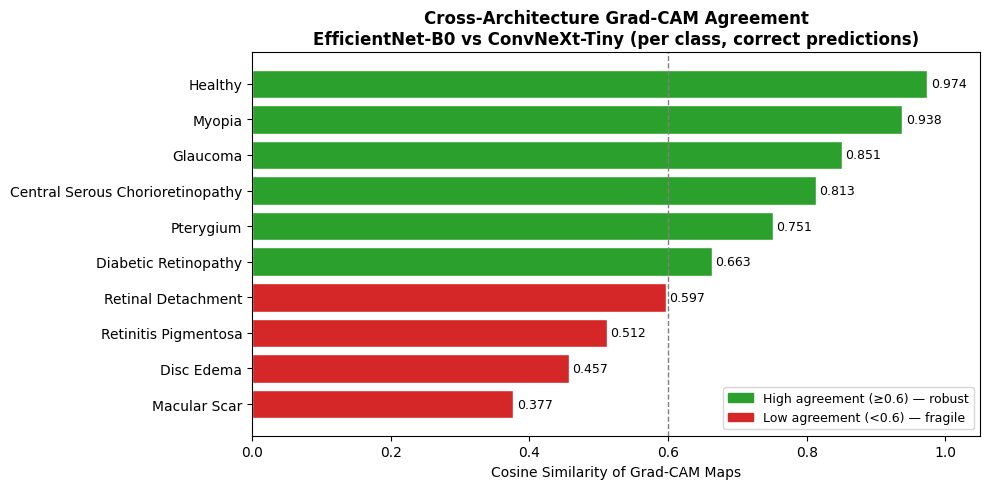

Saved → figures/gradcam/cam_agreement_by_class.png

                           class  agreement
                    Macular Scar      0.377
                      Disc Edema      0.457
            Retinitis Pigmentosa      0.512
              Retinal Detachment      0.597
            Diabetic Retinopathy      0.663
                       Pterygium      0.751
Central Serous Chorioretinopathy      0.813
                        Glaucoma      0.851
                          Myopia      0.938
                         Healthy      0.974


In [12]:
# Quantify cross-architecture CAM agreement per class
# High agreement: both models attend to the same region (feature is likely real)
# Low agreement : models disagree on what to look at (prediction may be fragile)

df_agreement = pd.DataFrame(agreement_scores).sort_values('agreement')

fig, ax = plt.subplots(figsize=(10, 5))
colours = ['#d62728' if a < 0.6 else '#2ca02c' for a in df_agreement['agreement']]
bars = ax.barh(df_agreement['class'], df_agreement['agreement'],
               color=colours, edgecolor='white')

for bar, val in zip(bars, df_agreement['agreement']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

ax.axvline(0.6, color='grey', linestyle='--', linewidth=1, label='Agreement threshold (0.6)')
ax.set_xlabel('Cosine Similarity of Grad-CAM Maps')
ax.set_title(
    'Cross-Architecture Grad-CAM Agreement\n'
    'EfficientNet-B0 vs ConvNeXt-Tiny (per class, correct predictions)',
    fontweight='bold'
)
ax.legend(fontsize=9)
ax.set_xlim(0, 1.05)

red_patch   = mpatches.Patch(color='#d62728', label='Low agreement (<0.6) — fragile')
green_patch = mpatches.Patch(color='#2ca02c', label='High agreement (≥0.6) — robust')
ax.legend(handles=[green_patch, red_patch], fontsize=9)

plt.tight_layout()
plt.savefig(GRADCAM_DIR / 'cam_agreement_by_class.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/gradcam/cam_agreement_by_class.png')
print()
print(df_agreement.to_string(index=False))

---
## 6. Fragile Prediction Detection

In [13]:
# Detect predictions where CAM attends to background
# Strategy: use the disc mask from EDA to separate foreground (disc) from
# background. Measure what fraction of CAM activation falls outside the disc.
# High outside-disc activation on a correct prediction = fragile.
# Running on both models allows cross-architecture comparison:
#   Agreement on fragility points to a dataset or class level issue
#   Disagreement points to architecture specific behaviour

def extract_disc_mask(img_bgr: np.ndarray) -> np.ndarray:
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    _, mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask)
    if num_labels > 1:
        largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        mask = (labels == largest).astype(np.uint8) * 255
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours and len(max(contours, key=cv2.contourArea)) >= 5:
        ellipse = cv2.fitEllipse(max(contours, key=cv2.contourArea))
        mask = np.zeros_like(mask)
        cv2.ellipse(mask, ellipse, 255, -1)
    return mask


def background_activation_ratio(cam: np.ndarray, mask: np.ndarray) -> float:
    """
    Fraction of total CAM activation that falls outside the disc mask.
    0 = all activation inside disc (ideal)
    1 = all activation outside disc (fragile)
    """
    cam_resized = cv2.resize(cam, (mask.shape[1], mask.shape[0]))
    total       = cam_resized.sum() + 1e-8
    outside     = cam_resized[mask == 0].sum()
    return float(outside / total)


SAMPLE_PER_CLASS = 5
fragility_records = []

# ConvNeXt is the best model; EfficientNet provides the comparison baseline
for model_name, model, preds in [
    ('EfficientNet-B0', effnet_model,   effnet_preds),
    ('ConvNeXt-Tiny',   convnext_model, convnext_preds),
]:
    cam_extractor = effnet_cam if model_name == 'EfficientNet-B0' else convnext_cam
    for class_idx in range(NUM_CLASSES):
        correct_mask = (preds == class_idx) & (test_labels == class_idx)
        idxs = np.where(correct_mask)[0][:SAMPLE_PER_CLASS]
        if len(idxs) == 0:
            continue
        for idx in tqdm(idxs, desc=f'{model_name} {CLASS_NAMES[class_idx]}', leave=False):
            img_path = test_paths[idx]
            try:
                img_bgr  = cv2.imread(str(img_path))
                img_np, _, _, conf, cam_np, _ = get_gradcam(
                    model, cam_extractor, img_path, DEVICE
                )
                mask     = extract_disc_mask(img_bgr)
                bg_ratio = background_activation_ratio(cam_np, mask)
                fragility_records.append({
                    'model':      model_name,
                    'class':      CLASS_NAMES[class_idx],
                    'path':       str(img_path),
                    'confidence': round(conf, 3),
                    'bg_ratio':   round(bg_ratio, 3),
                    'fragile':    bg_ratio > 0.4,
                })
            except Exception as e:
                print(f'Error on {img_path}: {e}')

df_fragility = pd.DataFrame(fragility_records)
print(f'Fragility analysis: {len(df_fragility)} images across both architectures')
print(f'Flagged as fragile: {df_fragility["fragile"].sum()} '
      f'({df_fragility["fragile"].mean()*100:.1f}%)')


Fragility analysis: 96 images across both architectures
Flagged as fragile: 0 (0.0%)


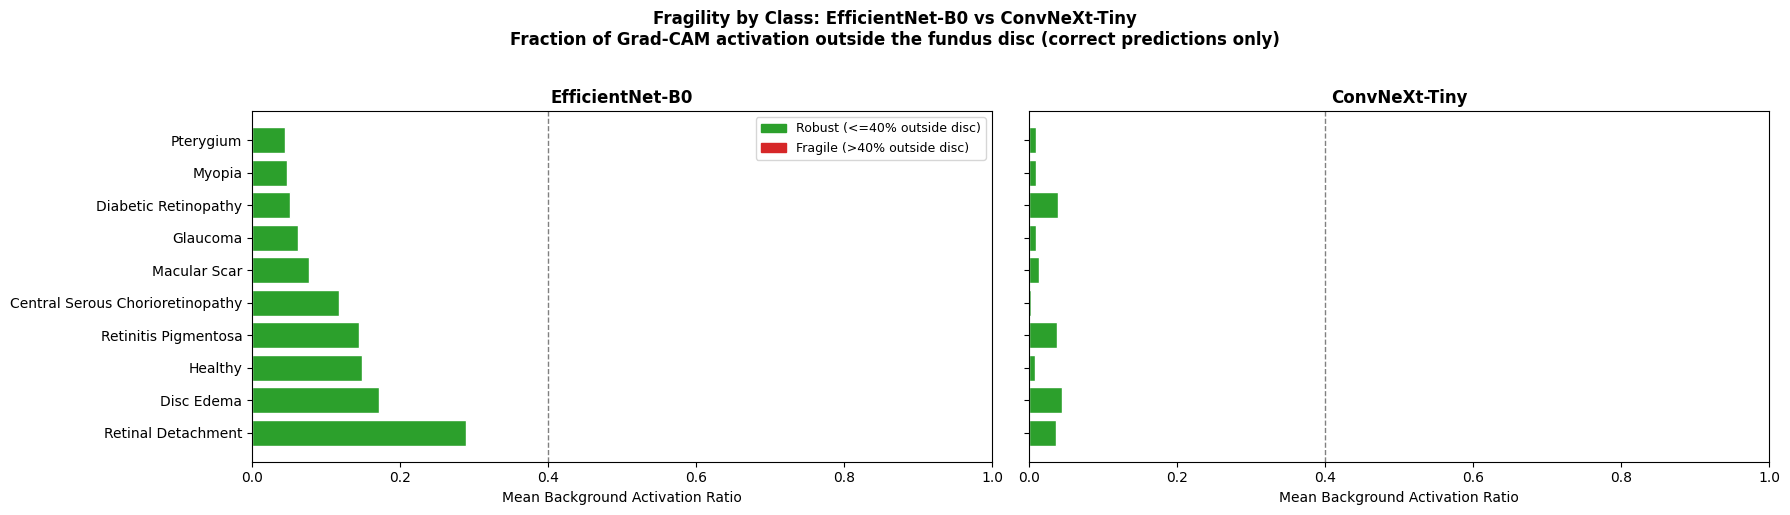

Saved to figures/gradcam/fragility_by_class.png


In [14]:
# Fragility by class for both architectures
fragility_by_class = (
    df_fragility.groupby(['model', 'class'])['bg_ratio']
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(18, 5), sharey=True)

for ax, (model_name, colour) in zip(axes, [
    ('EfficientNet-B0', 'steelblue'),
    ('ConvNeXt-Tiny',   'darkorange'),
]):
    data = (
        fragility_by_class[fragility_by_class['model'] == model_name]
        .sort_values('bg_ratio', ascending=False)
    )
    bar_colours = ['#d62728' if v > 0.4 else '#2ca02c' for v in data['bg_ratio']]
    ax.barh(data['class'], data['bg_ratio'], color=bar_colours, edgecolor='white')
    ax.axvline(0.4, color='grey', linestyle='--', linewidth=1)
    ax.set_title(model_name, fontweight='bold')
    ax.set_xlabel('Mean Background Activation Ratio')
    ax.set_xlim(0, 1.0)

red_patch   = mpatches.Patch(color='#d62728', label='Fragile (>40% outside disc)')
green_patch = mpatches.Patch(color='#2ca02c', label='Robust (<=40% outside disc)')
axes[0].legend(handles=[green_patch, red_patch], fontsize=9)

plt.suptitle(
    'Fragility by Class: EfficientNet-B0 vs ConvNeXt-Tiny\n'
    'Fraction of Grad-CAM activation outside the fundus disc (correct predictions only)',
    fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(GRADCAM_DIR / 'fragility_by_class.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to figures/gradcam/fragility_by_class.png')


In [15]:
# Show most fragile examples from ConvNeXt (best model)
# Correct predictions where the model attends to the wrong region

convnext_fragility = df_fragility[
    (df_fragility['model'] == 'ConvNeXt-Tiny') &
    (df_fragility['fragile'])
]
most_fragile = convnext_fragility.nlargest(3, 'bg_ratio')

if len(most_fragile) == 0:
    print('No fragile predictions detected for ConvNeXt: all predictions attend to disc region.')
else:
    fig, axes = plt.subplots(len(most_fragile), 3, figsize=(13, 4.5 * len(most_fragile)))
    if len(most_fragile) == 1:
        axes = [axes]

    for row, (_, record) in enumerate(most_fragile.iterrows()):
        img_bgr = cv2.imread(record['path'])
        img_np, _, pred_name, conf, cam_np, overlay = get_gradcam(
            convnext_model, convnext_cam, record['path'], DEVICE
        )
        mask = extract_disc_mask(img_bgr)
        mask_vis = cv2.resize(mask, (224, 224))

        axes[row][0].imshow(img_np, cmap='gray')
        axes[row][0].set_title(f'True: {record["class"]}', fontweight='bold', fontsize=9)

        axes[row][1].imshow(overlay)
        axes[row][1].set_title(
            f'Grad-CAM | Pred: {pred_name} ({conf:.2f})\n'
            f'BG ratio: {record["bg_ratio"]:.3f} FRAGILE',
            fontsize=9, color='#d62728'
        )

        cam_rgb = plt.cm.jet(cam_np)[:, :, :3]
        contours, _ = cv2.findContours(
            mask_vis, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
        )
        cam_bgr = (cam_rgb * 255).astype(np.uint8)
        cv2.drawContours(cam_bgr, contours, -1, (255, 255, 255), 2)
        axes[row][2].imshow(cam_bgr)
        axes[row][2].set_title(
            'CAM with disc boundary\n(activation should stay inside)', fontsize=9
        )

        for ax in axes[row]:
            ax.axis('off')

    plt.suptitle(
        'Fragile Predictions (ConvNeXt-Tiny): Correct But Attending to Wrong Region',
        fontweight='bold', y=1.01
    )
    plt.tight_layout()
    plt.savefig(GRADCAM_DIR / 'fragile_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved to figures/gradcam/fragile_predictions.png')


No fragile predictions detected for ConvNeXt: all predictions attend to disc region.


---
## 7. Explainability Summary

In [16]:
# Print structured summary
print('=' * 65)
print('EXPLAINABILITY SUMMARY')
print('=' * 65)

print('\nCross-Architecture CAM Agreement (EfficientNet vs ConvNeXt):')
for _, row in df_agreement.sort_values('agreement', ascending=False).iterrows():
    status = 'Robust' if row['agreement'] >= 0.6 else 'Fragile'
    print(f'  {row["class"]:<40} {row["agreement"]:.3f}  {status}')

print('\nBackground Activation by Class and Architecture:')
for model_name in ['EfficientNet-B0', 'ConvNeXt-Tiny']:
    print(f'\n  {model_name}:')
    data = (
        df_fragility[df_fragility['model'] == model_name]
        .groupby('class')['bg_ratio'].mean()
        .sort_values(ascending=False)
    )
    for cls, val in data.items():
        status = 'Fragile' if val > 0.4 else 'Robust'
        print(f'    {cls:<40} {val:.3f}  {status}')

print('\nCross-Architecture Fragility Agreement:')
print('(Whether both models agree on which classes are fragile)')
pivot = (
    df_fragility.groupby(['class', 'model'])['fragile']
    .mean()
    .unstack()
)
for cls, row in pivot.iterrows():
    e_frag = row.get('EfficientNet-B0', 0) > 0.4
    c_frag = row.get('ConvNeXt-Tiny', 0) > 0.4
    if e_frag and c_frag:
        signal = 'Both fragile   pointing to a dataset or class level issue'
    elif not e_frag and not c_frag:
        signal = 'Both robust    predictions are trustworthy'
    else:
        signal = 'Disagree       architecture specific behaviour'
    print(f'  {cls:<40} {signal}')

print('\nFIGURES SAVED')
for f in sorted(GRADCAM_DIR.glob('*.png')):
    print(f'  {f.relative_to(REPO_DIR)}')
print('=' * 65)
print('\nNOTE:')
print('Classes where both models are fragile point to dataset level issues')
print('such as imaging artefacts or insufficient training examples.')
print('These should be discussed in the Limitations section.')


EXPLAINABILITY SUMMARY

Cross-Architecture CAM Agreement (EfficientNet vs ConvNeXt):
  Healthy                                  0.974  Robust
  Myopia                                   0.938  Robust
  Glaucoma                                 0.851  Robust
  Central Serous Chorioretinopathy         0.813  Robust
  Pterygium                                0.751  Robust
  Diabetic Retinopathy                     0.663  Robust
  Retinal Detachment                       0.597  Fragile
  Retinitis Pigmentosa                     0.512  Fragile
  Disc Edema                               0.457  Fragile
  Macular Scar                             0.377  Fragile

Background Activation by Class and Architecture:

  EfficientNet-B0:
    Retinal Detachment                       0.289  Robust
    Disc Edema                               0.172  Robust
    Healthy                                  0.149  Robust
    Retinitis Pigmentosa                     0.145  Robust
    Central Serous Chorioretinopath

---
## 8. Commit and Push

In [17]:
NB_SRC  = Path('/content/drive/MyDrive/Colab Notebooks/04_Explainability_GradCAM.ipynb')
NB_DEST = REPO_DIR / 'notebooks' / '04_Explainability_GradCAM.ipynb'
NB_DEST.parent.mkdir(parents=True, exist_ok=True)

if NB_SRC.exists():
    shutil.copy(NB_SRC, NB_DEST)
    print(f'Copied → {NB_DEST}')

assert NB_DEST.exists(), f'Copy failed: {NB_DEST} not found'

%cd {REPO_DIR}
!git add notebooks/04_Explainability_GradCAM.ipynb figures/gradcam/
!git status
!git commit -m "Explainability: Grad-CAM gallery, cross-architecture agreement, fragile prediction analysis"
!git push
print('Done; Notebook 04 committed and pushed.')

AssertionError: Copy failed: /content/retinal-disease-classification/notebooks/04_Explainability_GradCAM.ipynb not found